In [1]:
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu118 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 4.5 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 72.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 40.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 99.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 11.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 33.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 9.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.7 MB/s eta 0:00:00
Device : cuda
PyTorch: 2.3.1+cu118
Total train samples: 3342
Train: 2841 | Val: 501

  Model  : H2Former
  Params : 2.27M
  Device : cuda
  Ep 001 | Loss:0.6581 | Dice:0.5473 | IoU:0.4147 | PixAcc:0.9880 | Acc:0.9880 | Prec:0.5045 | Rec:0.6896 | Spec:0.9911
  Ep 010 | Loss:0.3976 | Dice:0.8388 | IoU:0.7326 | PixAcc:0.9966 | Acc:0.9966 | Prec:0.8142 | Rec:0.8480 | Spec:0.9981
  Ep 020 | Loss:0.2493 | Dice:0.8440 | IoU:0.7463 | PixAcc:0.9969 | Acc:0.9969 | Prec:0.8171 | Rec:0.8843 | Spec:0.9980
  Ep 030 | Loss:0.0696 | Dice:0.8578 | IoU:0.7677 | PixAcc:0.9974 | Acc:0.9974 | Prec:0.8543 | Rec:0.8733 | Spec:0.9985
  Ep 040 | Loss:0.0476 | Dice:0.8675 | IoU:0.7824 | PixAcc:0.9976 | Acc:0.9976 | Prec:0.8647 | Rec:0.8809 | Spec:0.9986
  Ep 050 | Loss:0.0427 | Dice:0.8680 | IoU:0.7833 | PixAcc:0.9976 | Acc:0.9976 | Prec:0.8725 | Rec:0.8749 | Spec:0.9987
  Early stop at epoch 54.

  H2Former TRAINING COMPLETE
  Bes

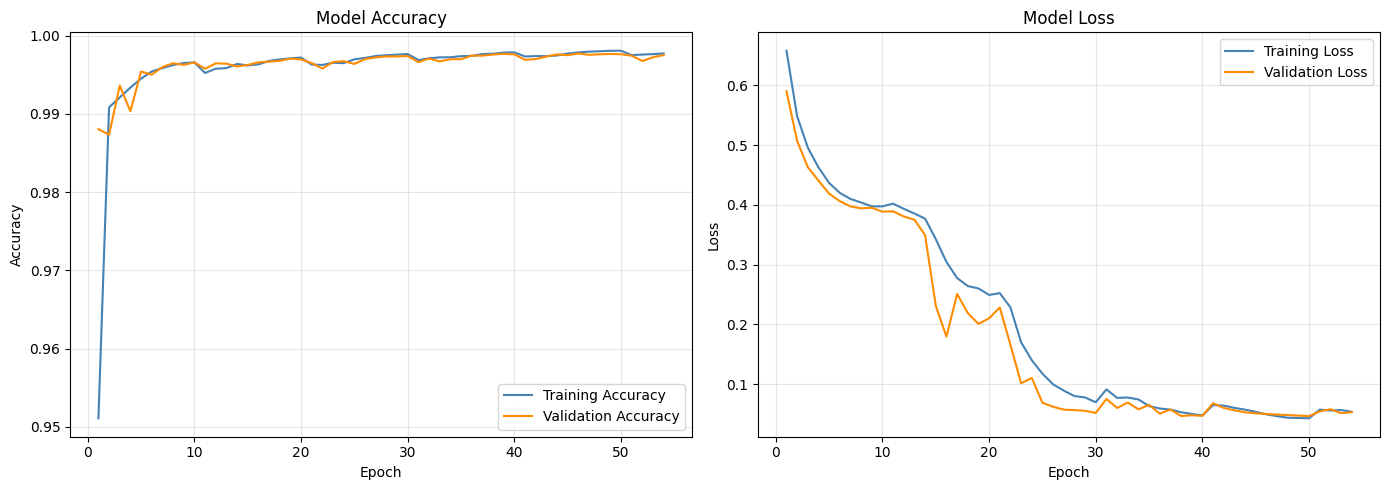

Plot saved to /kaggle/working/H2Former_history.png

--- Evaluating on Train Set ---
Total train samples: 3342
Train: 2841 | Val: 501

  TRAIN EVALUATION
  Loss       : 0.0471
  Dice       : 86.50%
  IoU        : 78.04%
  Pixel Acc  : 99.77%
  Accuracy   : 99.77%
  Precision  : 83.44%
  Recall     : 86.07%
  Specificity: 99.88%

--- Evaluating on Validation Set ---
Total train samples: 3342
Train: 2841 | Val: 501

  VALIDATION EVALUATION
  Loss       : 0.0403
  Dice       : 87.23%
  IoU        : 79.78%
  Pixel Acc  : 99.82%
  Accuracy   : 99.82%
  Precision  : 81.17%
  Recall     : 84.42%
  Specificity: 99.90%

--- Evaluating on Test Set ---
Total test samples: 587

  TEST EVALUATION
  Loss       : 0.0555
  Dice       : 85.64%
  IoU        : 79.25%
  Pixel Acc  : 99.71%
  Accuracy   : 99.71%
  Precision  : 50.70%
  Recall     : 46.22%
  Specificity: 99.87%

[FINAL RESULT] H2Former → Val Dice: 88.00% | Test IoU: 79.25%


In [2]:
import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch", "einops", "-q"], check=True)

import os, glob, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

BASE_PATH     = "/kaggle/input/datasets/ahmadnafeestihami/lgg2d-slices"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MSK_DIR = os.path.join(BASE_PATH, "train/masks")
TEST_IMG_DIR  = os.path.join(BASE_PATH, "test/images")
TEST_MSK_DIR  = os.path.join(BASE_PATH, "test/masks")

CFG = dict(
    img_size     = 256,
    batch_size   = 8,
    lr           = 1e-4,
    weight_decay = 1e-5,
    epochs       = 80,
    patience     = 10,
    val_split    = 0.15,
    device       = "cuda" if torch.cuda.is_available() else "cpu",
)
print(f"Device : {CFG['device']}")
print(f"PyTorch: {torch.__version__}")


class BRISCDataset(Dataset):
    def __init__(self, img_paths, mask_paths, img_size=256, augment=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.img_size   = img_size
        self.augment    = augment

    def __len__(self):
        return len(self.img_paths)

    def _load(self, path, gray=False):
        img = Image.open(path).convert("L" if gray else "RGB")
        return img.resize((self.img_size, self.img_size), Image.BILINEAR)

    def __getitem__(self, idx):
        img  = self._load(self.img_paths[idx])
        mask = self._load(self.mask_paths[idx], gray=True)
        if self.augment:
            if random.random() > 0.5: img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() > 0.5: img, mask = TF.vflip(img), TF.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            if angle:
                img  = TF.rotate(img,  angle)
                mask = TF.rotate(mask, angle)
            img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
            img = TF.adjust_contrast(img,   random.uniform(0.8, 1.2))
        img  = TF.to_tensor(img)
        img  = TF.normalize(img, [0.5]*3, [0.5]*3)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()
        return img, mask


def get_loaders():
    img_paths  = sorted(glob.glob(os.path.join(TRAIN_IMG_DIR, "*")))
    mask_paths = sorted(glob.glob(os.path.join(TRAIN_MSK_DIR, "*")))
    assert len(img_paths) > 0, f"No images found at {TRAIN_IMG_DIR}"
    assert len(img_paths) == len(mask_paths), "Image/mask count mismatch!"
    print(f"Total train samples: {len(img_paths)}")
    idx = list(range(len(img_paths)))
    random.shuffle(idx)
    n_val = int(len(idx) * CFG["val_split"])
    t_idx, v_idx = idx[n_val:], idx[:n_val]
    train_ds = BRISCDataset([img_paths[i] for i in t_idx],
                             [mask_paths[i] for i in t_idx],
                             CFG["img_size"], augment=True)
    val_ds   = BRISCDataset([img_paths[i] for i in v_idx],
                             [mask_paths[i] for i in v_idx],
                             CFG["img_size"], augment=False)
    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=2, pin_memory=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
    return train_loader, val_loader


def get_test_loader():
    img_paths  = sorted(glob.glob(os.path.join(TEST_IMG_DIR, "*")))
    mask_paths = sorted(glob.glob(os.path.join(TEST_MSK_DIR, "*")))
    assert len(img_paths) > 0, f"No test images found at {TEST_IMG_DIR}"
    print(f"Total test samples: {len(img_paths)}")
    test_ds = BRISCDataset(img_paths, mask_paths, CFG["img_size"], augment=False)
    return DataLoader(test_ds, batch_size=CFG["batch_size"],
                      shuffle=False, num_workers=2, pin_memory=True)


class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        prob  = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(2, 3))
        dice  = 1 - (2*inter + self.smooth) / (
                    prob.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return 0.5 * dice.mean() + 0.5 * bce


def compute_metrics(logits, masks, thresh=0.5):
    preds = (torch.sigmoid(logits) > thresh).float()
    inter = (preds * masks).sum()
    dice  = (2*inter + 1) / (preds.sum() + masks.sum() + 1)
    iou   = (inter + 1)   / (preds.sum() + masks.sum() - inter + 1)
    acc   = (preds == masks).float().mean()
    tp    = ((preds==1)&(masks==1)).sum().float()
    tn    = ((preds==0)&(masks==0)).sum().float()
    fp    = ((preds==1)&(masks==0)).sum().float()
    fn    = ((preds==0)&(masks==1)).sum().float()
    prec  = tp / (tp + fp + 1e-7)
    rec   = tp / (tp + fn + 1e-7)
    spec  = tn / (tn + fp + 1e-7)
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    return dice.item(), iou.item(), acc.item(), prec.item(), rec.item(), spec.item(), pixel_acc.item()


def evaluate_split(model, loader, device, split_name):
    model.eval()
    criterion = DiceBCELoss()
    total_loss = 0.0
    v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs)
            if out.shape[-2:] != masks.shape[-2:]:
                out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
            total_loss += criterion(out, masks).item()
            d, i, a, p, r, s, px = compute_metrics(out, masks)
            v_dice += d; v_iou += i; v_acc += a
            v_prec += p; v_rec += r; v_spec += s; v_pix += px
    n = len(loader)
    print(f"\n{'='*60}")
    print(f"  {split_name} EVALUATION")
    print(f"{'='*60}")
    print(f"  Loss       : {total_loss/n:.4f}")
    print(f"  Dice       : {v_dice/n*100:.2f}%")
    print(f"  IoU        : {v_iou/n*100:.2f}%")
    print(f"  Pixel Acc  : {v_pix/n*100:.2f}%")
    print(f"  Accuracy   : {v_acc/n*100:.2f}%")
    print(f"  Precision  : {v_prec/n*100:.2f}%")
    print(f"  Recall     : {v_rec/n*100:.2f}%")
    print(f"  Specificity: {v_spec/n*100:.2f}%")
    print(f"{'='*60}")
    return v_dice/n, v_iou/n


def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history["train_acc"], color='steelblue',  linewidth=1.5, label="Training Accuracy")
    axes[0].plot(epochs, history["val_acc"],   color='darkorange', linewidth=1.5, label="Validation Accuracy")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history["train_loss"], color='steelblue',  linewidth=1.5, label="Training Loss")
    axes[1].plot(epochs, history["val_loss"],   color='darkorange', linewidth=1.5, label="Validation Loss")
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{model_name}_history.png", dpi=150)
    plt.show()
    print(f"Plot saved to /kaggle/working/{model_name}_history.png")


class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ChannelAttn(nn.Module):
    def __init__(self, ch, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, max(ch // reduction, 4)),
            nn.ReLU(inplace=True),
            nn.Linear(max(ch // reduction, 4), ch),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.fc(x).view(x.shape[0], x.shape[1], 1, 1)


class SpatialAttn(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, groups=ch, bias=False),
            nn.Conv2d(ch, ch, 1, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, groups=ch, bias=False),
            nn.Conv2d(ch, ch, 1, bias=False),
            nn.BatchNorm2d(ch),
        )
    def forward(self, x):
        return x + self.conv(x)


class GlobalAttnBottleneck(nn.Module):
    def __init__(self, ch, num_heads=4, pool_size=4):
        super().__init__()
        self.pool_size = pool_size
        self.norm      = nn.LayerNorm(ch)
        self.num_heads = num_heads
        self.head_dim  = ch // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(ch, ch * 3, bias=False)
        self.proj      = nn.Linear(ch, ch, bias=False)

    def forward(self, x):
        B, C, H, W = x.shape
        p   = self.pool_size
        xp  = F.adaptive_avg_pool2d(x, p)
        seq = xp.flatten(2).transpose(1, 2)
        seq = self.norm(seq)
        N   = seq.shape[1]
        qkv = self.qkv(seq).reshape(B, N, 3, self.num_heads,
                                     self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = attn.softmax(dim=-1)
        out  = (attn @ v).transpose(1,2).reshape(B, N, C)
        out  = self.proj(out)
        out  = out.transpose(1,2).reshape(B, C, p, p)
        out  = F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)
        return x + out


class H2FormerBlock(nn.Module):
    def __init__(self, ch, use_global=False, num_heads=4, pool_size=4):
        super().__init__()
        self.local_h    = SpatialAttn(ch)
        self.local_c    = ChannelAttn(ch)
        self.use_global = use_global
        if use_global:
            self.global_attn = GlobalAttnBottleneck(ch, num_heads=num_heads,
                                                     pool_size=pool_size)
        self.fuse = nn.Sequential(
            nn.Conv2d(ch, ch, 1, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        lh  = self.local_h(x)
        lc  = self.local_c(x)
        out = lh + lc
        if self.use_global:
            out = self.global_attn(out)
        return self.fuse(out) + x


class H2Former(nn.Module):
    def __init__(self, in_ch=3, num_classes=1, base=32):
        super().__init__()
        f = [base, base*2, base*4, base*8]

        self.stem  = ConvBNReLU(in_ch, f[0])

        self.enc1  = H2FormerBlock(f[0], use_global=False)
        self.down1 = nn.Sequential(
            nn.Conv2d(f[0], f[1], 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(f[1]), nn.ReLU(inplace=True),
        )

        self.enc2  = H2FormerBlock(f[1], use_global=False)
        self.down2 = nn.Sequential(
            nn.Conv2d(f[1], f[2], 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(f[2]), nn.ReLU(inplace=True),
        )

        self.enc3  = H2FormerBlock(f[2], use_global=False)
        self.down3 = nn.Sequential(
            nn.Conv2d(f[2], f[3], 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(f[3]), nn.ReLU(inplace=True),
        )

        self.btn   = nn.Sequential(
            H2FormerBlock(f[3], use_global=True, num_heads=4, pool_size=4),
            H2FormerBlock(f[3], use_global=True, num_heads=4, pool_size=4),
        )

        self.up3   = nn.ConvTranspose2d(f[3], f[2], 2, stride=2)
        self.fuse3 = ConvBNReLU(f[2]*2, f[2])
        self.dec3  = H2FormerBlock(f[2], use_global=False)

        self.up2   = nn.ConvTranspose2d(f[2], f[1], 2, stride=2)
        self.fuse2 = ConvBNReLU(f[1]*2, f[1])
        self.dec2  = H2FormerBlock(f[1], use_global=False)

        self.up1   = nn.ConvTranspose2d(f[1], f[0], 2, stride=2)
        self.fuse1 = ConvBNReLU(f[0]*2, f[0])
        self.dec1  = H2FormerBlock(f[0], use_global=False)

        self.dropout = nn.Dropout2d(0.3)
        self.head    = nn.Conv2d(f[0], num_classes, 1)

    def forward(self, x):
        s  = self.stem(x)
        e1 = self.enc1(s)
        e2 = self.enc2(self.down1(e1))
        e3 = self.enc3(self.down2(e2))
        b  = self.btn(self.down3(e3))
        d3 = self.dec3(self.fuse3(torch.cat([self.up3(b),  e3], 1)))
        d2 = self.dec2(self.fuse2(torch.cat([self.up2(d3), e2], 1)))
        d1 = self.dec1(self.fuse1(torch.cat([self.up1(d2), e1], 1)))
        return self.head(self.dropout(d1))


def train_model(model, model_name):
    device = CFG["device"]
    model  = model.to(device)
    train_loader, val_loader = get_loaders()
    criterion = DiceBCELoss()
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)
    best_dice, no_improve = 0.0, 0
    best_weights = None
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"  Model  : {model_name}")
    print(f"  Params : {n_params/1e6:.2f}M")
    print(f"  Device : {device}")
    print(f"{'='*60}")

    for epoch in range(1, CFG["epochs"] + 1):
        model.train()
        t_loss = 0.0
        t_acc  = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            if out.shape[-2:] != masks.shape[-2:]:
                out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
            loss = criterion(out, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
            _, _, a, _, _, _, _ = compute_metrics(out, masks)
            t_acc += a
        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)

        model.eval()
        v_loss = 0.0
        v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                out = model(imgs)
                if out.shape[-2:] != masks.shape[-2:]:
                    out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                v_loss += criterion(out, masks).item()
                d, i, a, p, r, s, px = compute_metrics(out, masks)
                v_dice += d; v_iou += i; v_acc += a
                v_prec += p; v_rec += r; v_spec += s; v_pix += px

        n = len(val_loader)
        v_loss /= n
        v_dice /= n; v_iou /= n; v_acc /= n
        v_prec /= n; v_rec /= n; v_spec /= n; v_pix /= n

        scheduler.step()
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:03d} | Loss:{t_loss:.4f} | "
                  f"Dice:{v_dice:.4f} | IoU:{v_iou:.4f} | "
                  f"PixAcc:{v_pix:.4f} | Acc:{v_acc:.4f} | "
                  f"Prec:{v_prec:.4f} | Rec:{v_rec:.4f} | Spec:{v_spec:.4f}")

        if v_dice > best_dice:
            best_dice    = v_dice
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= CFG["patience"]:
                print(f"  Early stop at epoch {epoch}.")
                break

    model.load_state_dict(best_weights)
    print(f"\n{'='*60}")
    print(f"  {model_name} TRAINING COMPLETE")
    print(f"  Best Val Dice : {best_dice*100:.2f}%")
    print(f"{'='*60}")
    plot_history(history, model_name)

    print("\n--- Evaluating on Train Set ---")
    train_loader_eval, _ = get_loaders()
    evaluate_split(model, train_loader_eval, device, "TRAIN")

    print("\n--- Evaluating on Validation Set ---")
    _, val_loader_eval = get_loaders()
    evaluate_split(model, val_loader_eval, device, "VALIDATION")

    print("\n--- Evaluating on Test Set ---")
    test_loader = get_test_loader()
    test_dice, test_iou = evaluate_split(model, test_loader, device, "TEST")

    return model, history, best_dice, test_iou


model_h2former = H2Former(in_ch=3, num_classes=1, base=32)
model_h2former, history_h2former, dice_h2former, iou_h2former = train_model(model_h2former, "H2Former")
print(f"\n[FINAL RESULT] H2Former → Val Dice: {dice_h2former*100:.2f}% | Test IoU: {iou_h2former*100:.2f}%")